<a href="https://colab.research.google.com/github/Kireeti2808/agri_doctor/blob/main/Cotton_Weed_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("parthajyotiroyjoy/cotton-plant-disease-dataset")

print("Path to dataset files:", path)


100%|██████████| 258M/258M [00:03<00:00, 89.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/parthajyotiroyjoy/cotton-plant-disease-dataset/versions/1


In [ ]:
import os

print("Top-level contents:")
print(os.listdir(path))


Top-level contents:
['Original Dataset']


In [ ]:
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"\nContents of {item}:")
        print(os.listdir(item_path))



Contents of Original Dataset:
['Healthy Leaf', 'Leaf Redding', 'Leaf Hopper Jassids', 'Curl Virus', 'Leaf Variegation', 'Herbicide Growth Damage', 'Bacterial Blight']


In [ ]:
import os

print("SOURCE path:", path)
print("\nSOURCE contents:")
print(os.listdir(path))


SOURCE path: /root/.cache/kagglehub/datasets/parthajyotiroyjoy/cotton-plant-disease-dataset/versions/1

SOURCE contents:
['Original Dataset']


In [ ]:
import os
import shutil

SOURCE_BASE = "/root/.cache/kagglehub/datasets/parthajyotiroyjoy/cotton-plant-disease-dataset/versions/1/Original Dataset"
TARGET_BASE = "/content/dataset_disease_only_v2"

DISEASE_CLASSES = [
    "Healthy Leaf",
    "Bacterial Blight",
    "Curl Virus",
    "Leaf Variegation",
    "Leaf Redding",
    "Herbicide Growth Damage"
]

os.makedirs(TARGET_BASE, exist_ok=True)

print("SOURCE contents:")
print(os.listdir(SOURCE_BASE))

for cls in DISEASE_CLASSES:
    src = os.path.join(SOURCE_BASE, cls)
    dst = os.path.join(TARGET_BASE, cls)

    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"✅ Copied: {cls}")
    else:
        print(f"❌ Missing: {cls}")

print("\n✅ Disease-only dataset prepared")


SOURCE contents:
['Healthy Leaf', 'Leaf Redding', 'Leaf Hopper Jassids', 'Curl Virus', 'Leaf Variegation', 'Herbicide Growth Damage', 'Bacterial Blight']
✅ Copied: Healthy Leaf
✅ Copied: Bacterial Blight
✅ Copied: Curl Virus
✅ Copied: Leaf Variegation
✅ Copied: Leaf Redding
✅ Copied: Herbicide Growth Damage

✅ Disease-only dataset prepared


In [ ]:
import os
import shutil
import random

SOURCE_DIR = "/content/dataset_disease_only_v2"
TARGET_DIR = "/content/dataset_final_v2"

SPLIT_RATIO = {
    "train": 0.8,
    "val": 0.1,
    "test": 0.1
}

random.seed(42)

# Create folder structure
for split in SPLIT_RATIO:
    for cls in os.listdir(SOURCE_DIR):
        os.makedirs(os.path.join(TARGET_DIR, split, cls), exist_ok=True)

# Split images
for cls in os.listdir(SOURCE_DIR):
    cls_path = os.path.join(SOURCE_DIR, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(SPLIT_RATIO["train"] * total)
    val_end = train_end + int(SPLIT_RATIO["val"] * total)

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, split_imgs in splits.items():
        for img in split_imgs:
            src = os.path.join(cls_path, img)
            dst = os.path.join(TARGET_DIR, split, cls, img)
            shutil.copy(src, dst)

    print(f"{cls}: {total} images split")

print("\n✅ Train / Val / Test split (v2) completed")


Healthy Leaf: 257 images split
Leaf Redding: 578 images split
Curl Virus: 431 images split
Leaf Variegation: 116 images split
Herbicide Growth Damage: 280 images split
Bacterial Blight: 250 images split

✅ Train / Val / Test split (v2) completed


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Basic settings
IMG_SIZE = (224, 224)
NUM_CLASSES = 6
LEARNING_RATE = 1e-4

# Load pretrained MobileNetV2 (feature extractor)
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

# Freeze base model layers
base_model.trainable = False

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

# Final model
model = Model(inputs=base_model.input, outputs=outputs)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Show model summary
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 16   # slightly higher since dataset is bigger

train_dir = "/content/dataset_final_v2/train"
val_dir = "/content/dataset_final_v2/val"
test_dir = "/content/dataset_final_v2/test"

# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation & test (NO augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 1527 images belonging to 6 classes.
Found 189 images belonging to 6 classes.
Found 196 images belonging to 6 classes.


In [ ]:
EPOCHS = 15

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)


Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 98s 948ms/step - accuracy: 0.2992 - loss: 1.8660 - val_accuracy: 0.6561 - val_loss: 1.0181
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 90s 926ms/step - accuracy: 0.5707 - loss: 1.1657 - val_accuracy: 0.7460 - val_loss: 0.7639
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 90s 934ms/step - accuracy: 0.6740 - loss: 0.8754 - val_accuracy: 0.8201 - val_loss: 0.6156
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 92s 955ms/step - accuracy: 0.7504 - loss: 0.7032 - val_accuracy: 0.8360 - val_loss: 0.5337
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 92s 954ms/step - accuracy: 0.7336 - loss: 0.6772 - val_accuracy: 0.8413 - val_loss: 0.4693
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 86s 898ms/step - accuracy: 0.7964 - loss: 0.5704 - val_accuracy: 0.8360 - val_loss: 0.4362
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8326 - loss: 0.5160 - val_accuracy: 0.8624 - val_loss: 0.4138
Epoch 8/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 93s 965ms/step - accuracy: 0.8193 - loss: 0.5143 - val_accura

In [ ]:
test_loss, test_acc = model.evaluate(test_gen)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 696ms/step - accuracy: 0.8962 - loss: 0.3241
Test Accuracy: 0.9082
Test Loss: 0.2839


13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 810ms/step


<Figure size 800x800 with 0 Axes>

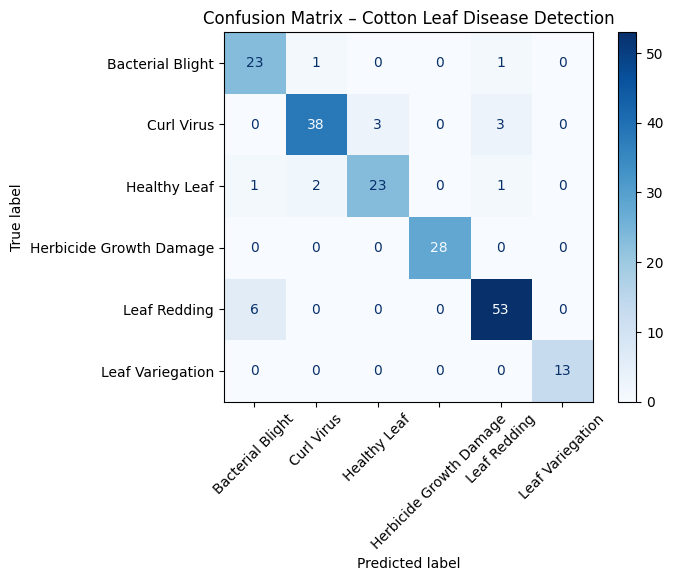

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get true labels and predictions
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(test_gen.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix – Cotton Leaf Disease Detection")
plt.show()


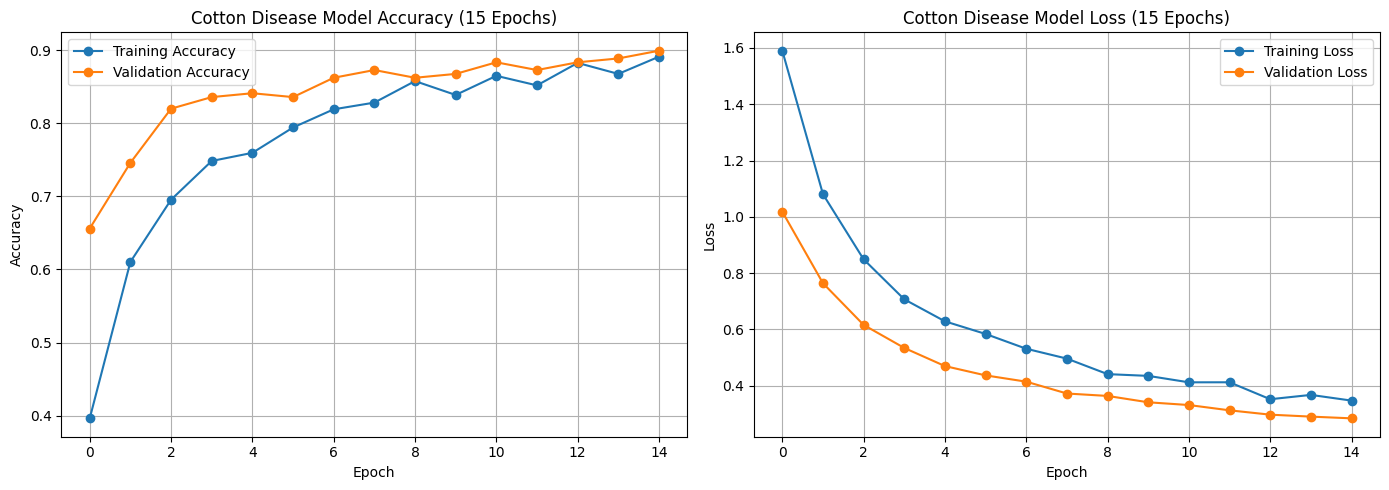

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.title("Cotton Disease Model Accuracy (15 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')
plt.title("Cotton Disease Model Loss (15 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 943ms/step
Accuracy: 90.82%

Classification Report:
                         precision    recall  f1-score   support

       Bacterial Blight       0.77      0.92      0.84        25
             Curl Virus       0.93      0.86      0.89        44
           Healthy Leaf       0.88      0.85      0.87        27
Herbicide Growth Damage       1.00      1.00      1.00        28
           Leaf Redding       0.91      0.90      0.91        59
       Leaf Variegation       1.00      1.00      1.00        13

               accuracy                           0.91       196
              macro avg       0.92      0.92      0.92       196
           weighted avg       0.91      0.91      0.91       196



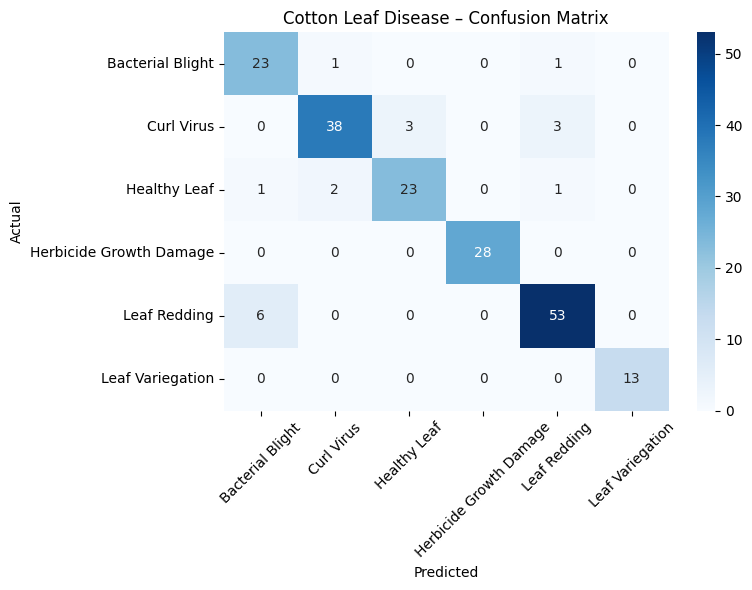

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Ground truth & predictions
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(test_gen.class_indices.keys())

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc * 100:.2f}%\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Cotton Leaf Disease – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
model.save("cotton_disease_model_v1.h5")
print("✅ Model saved as cotton_disease_model_v1.h5")


✅ Model saved as cotton_disease_model_v1.h5


In [ ]:
# from google.colab import files

# files.download("app.py")
# files.download("cotton_disease_model_v1.h5")


In [ ]:
%%writefile requirements.txt
streamlit
tensorflow
numpy
pillow
scikit-learn


Writing requirements.txt


In [ ]:
from google.colab import files
files.download("requirements.txt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("yuzhenlu/cottonweedid15")
print("Path to dataset files:", path)


100%|██████████| 10.5G/10.5G [06:11<00:00, 30.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yuzhenlu/cottonweedid15/versions/1


In [ ]:
import os

print("Top-level contents:")
print(os.listdir(path))


Top-level contents:
['CottonWeedID15']


In [ ]:
import os

base = os.path.join(path, "CottonWeedID15")

print("Contents of CottonWeedID15:")
print(os.listdir(base))


Contents of CottonWeedID15:
['Morningglory', 'SpottedSpurge', 'Crabgrass', 'Eclipta', 'Nutsedge', 'Prickly Sida', 'Waterhemp', 'Sicklepod', 'PalmerAmaranth', 'Purslane', 'Carpetweeds', 'SpurredAnoda', 'Swinecress', 'Ragweed', 'Goosegrass']


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Selected weed classes
weed_classes = [
    "Morningglory",
    "Carpetweeds",
    "PalmerAmaranth",
    "Waterhemp",
    "Purslane"
]

# Base paths
weed_source = base  # CottonWeedID15
weed_target = "/content/weed_dataset"

# Create directories
for split in ["train", "val", "test"]:
    for cls in weed_classes:
        os.makedirs(os.path.join(weed_target, split, cls), exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Copy images
for cls in weed_classes:
    cls_path = os.path.join(weed_source, cls)
    images = os.listdir(cls_path)

    train_imgs, temp_imgs = train_test_split(images, test_size=(1 - train_ratio), random_state=42)
    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=test_ratio / (val_ratio + test_ratio),
        random_state=42
    )

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(weed_target, "train", cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(weed_target, "val", cls, img))
    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(weed_target, "test", cls, img))

print("✅ Weed dataset prepared (train / val / test)")


✅ Weed dataset prepared (train / val / test)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_WEED_CLASSES = 5

train_dir = "/content/weed_dataset/train"
val_dir = "/content/weed_dataset/val"
test_dir = "/content/weed_dataset/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

weed_train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

weed_val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

weed_test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 2425 images belonging to 5 classes.
Found 520 images belonging to 5 classes.
Found 523 images belonging to 5 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load base model
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

# Freeze base layers
base_model.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_WEED_CLASSES, activation="softmax")(x)

weed_model = Model(inputs=base_model.input, outputs=outputs)

# Compile
weed_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

weed_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
EPOCHS = 15

weed_history = weed_model.fit(
    weed_train_gen,
    validation_data=weed_val_gen,
    epochs=EPOCHS
)


Epoch 1/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8374 - loss: 0.4608

In [ ]:
weed_test_loss, weed_test_acc = weed_model.evaluate(weed_test_gen)

print(f"🌱 Weed Test Accuracy: {weed_test_acc:.4f}")
print(f"🌱 Weed Test Loss: {weed_test_loss:.4f}")


33/33 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.8450 - loss: 0.4106
🌱 Weed Test Accuracy: 0.8298
🌱 Weed Test Loss: 0.4653


In [ ]:
weed_model.save("cotton_weed_model_v1.keras")
print("✅ Weed model saved as cotton_weed_model_v1.keras")


✅ Weed model saved as cotton_weed_model_v1.keras


In [ ]:
import numpy as np

y_true = weed_test_gen.classes
y_pred = weed_model.predict(weed_test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)


33/33 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step


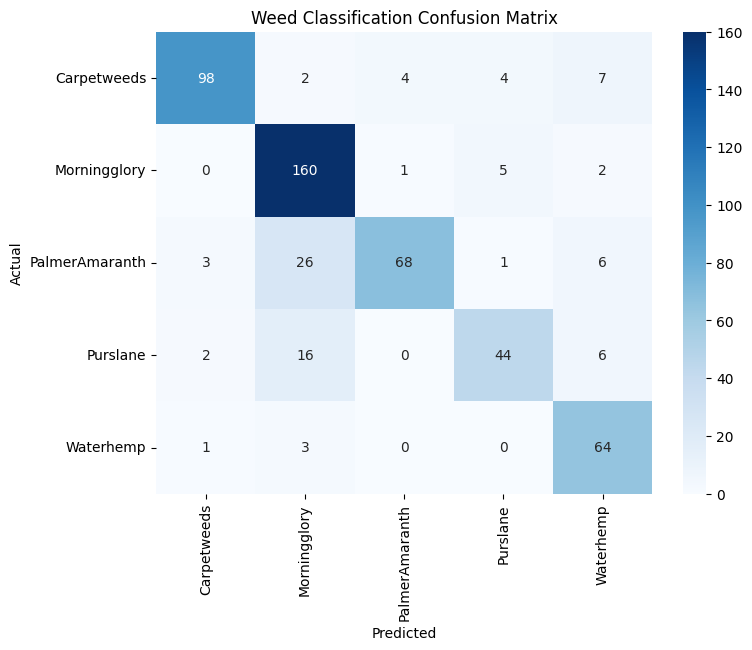

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)
class_names = list(weed_test_gen.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Weed Classification Confusion Matrix")
plt.show()


In [ ]:
print(classification_report(y_true, y_pred_classes, target_names=class_names))


                precision    recall  f1-score   support

   Carpetweeds       0.94      0.85      0.89       115
  Morningglory       0.77      0.95      0.85       168
PalmerAmaranth       0.93      0.65      0.77       104
      Purslane       0.81      0.65      0.72        68
     Waterhemp       0.75      0.94      0.84        68

      accuracy                           0.83       523
     macro avg       0.84      0.81      0.81       523
  weighted avg       0.84      0.83      0.83       523



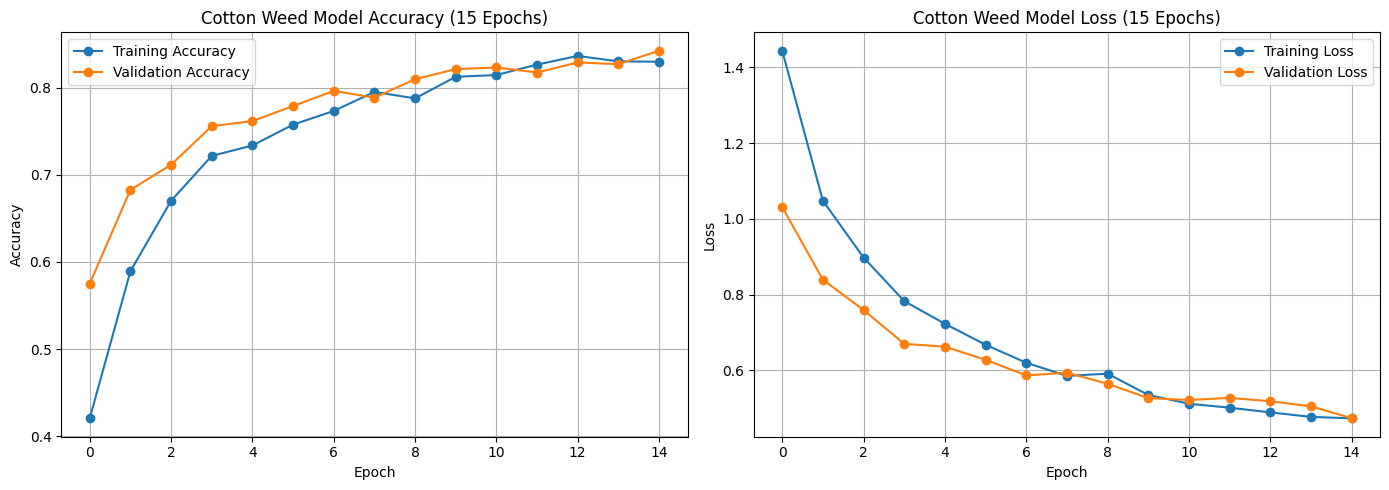

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(weed_history.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(weed_history.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.title("Cotton Weed Model Accuracy (15 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(weed_history.history['loss'], marker='o', label='Training Loss')
plt.plot(weed_history.history['val_loss'], marker='o', label='Validation Loss')
plt.title("Cotton Weed Model Loss (15 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


33/33 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step
Weed Model Accuracy: 82.98%

Classification Report:
                precision    recall  f1-score   support

   Carpetweeds       0.94      0.85      0.89       115
  Morningglory       0.77      0.95      0.85       168
PalmerAmaranth       0.93      0.65      0.77       104
      Purslane       0.81      0.65      0.72        68
     Waterhemp       0.75      0.94      0.84        68

      accuracy                           0.83       523
     macro avg       0.84      0.81      0.81       523
  weighted avg       0.84      0.83      0.83       523



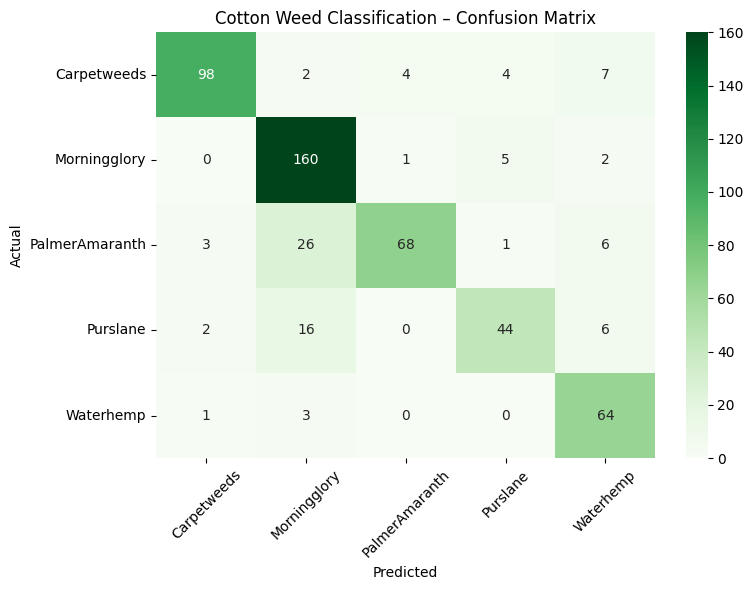

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Ground truth & predictions
y_true = weed_test_gen.classes
y_pred_probs = weed_model.predict(weed_test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(weed_test_gen.class_indices.keys())

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Weed Model Accuracy: {acc * 100:.2f}%\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Cotton Weed Classification – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
disease_classes = [
    "Healthy Leaf",
    "Bacterial Blight",
    "Curl Virus",
    "Leaf Variegation",
    "Leaf Redding",
    "Herbicide Growth Damage"
]

weed_classes = [
    "Carpetweeds",
    "Morningglory",
    "PalmerAmaranth",
    "Purslane",
    "Waterhemp"
]

print("✅ Class labels locked")


✅ Class labels locked


In [ ]:
from tensorflow.keras.models import load_model

disease_model = load_model("cotton_disease_model_v1.h5")
weed_model = load_model("cotton_weed_model_v1.keras")

print("✅ Both models loaded")


✅ Both models loaded


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img


In [ ]:
def predict_disease(img_path):
    img = preprocess_image(img_path)

    preds = disease_model.predict(img)[0]
    idx = np.argmax(preds)

    return {
        "type": "disease",
        "prediction": disease_classes[idx],
        "confidence": round(float(preds[idx] * 100), 2)
    }


In [ ]:
def predict_weed(img_path):
    img = preprocess_image(img_path)

    preds = weed_model.predict(img)[0]
    idx = np.argmax(preds)

    return {
        "type": "weed",
        "prediction": weed_classes[idx],
        "confidence": round(float(preds[idx] * 100), 2)
    }


In [ ]:
from google.colab import files

uploaded = files.upload()
uploaded.keys()


Saving LHJ00002.jpg to LHJ00002.jpg


dict_keys(['LHJ00002.jpg'])

In [ ]:
img_path = "/content/LHJ00002.jpg"

predict_disease(img_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


{'type': 'disease', 'prediction': 'Leaf Redding', 'confidence': 85.25}

In [ ]:
from tensorflow.keras.models import load_model

# Load models again
disease_model = load_model("cotton_disease_model_v1.h5")
weed_model = load_model("cotton_weed_model_v1.keras")

print("✅ Disease & Weed models loaded")


✅ Disease & Weed models loaded


In [ ]:
import os

print(os.listdir("/content"))


['.config', 'weed_dataset', 'dataset_final_v2', 'dataset_disease_only_v2', 'cotton_weed_model_v1.keras', 'requirements.txt', 'cotton_disease_model_v1.h5', 'LHJ00002.jpg', 'sample_data']


In [ ]:
import os

print(os.listdir("/content"))


['.config', 'weed_dataset', 'dataset_final_v2', 'dataset_disease_only_v2', 'cotton_weed_model_v1.keras', 'requirements.txt', 'cotton_disease_model_v1.h5', 'LHJ00002.jpg', 'sample_data']


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from PIL import Image

# ------------------------
# Page setup
# ------------------------
st.set_page_config(
    page_title="Cotton Crop Intelligence",
    page_icon="🌿",
    layout="centered"
)

st.title("🌿 Cotton Crop Intelligence System")
st.write("Detect **cotton leaf diseases** or **weed types** using AI")

# ------------------------
# Load models (cached)
# ------------------------
@st.cache_resource
def load_models():
    disease_model = load_model("cotton_disease_model_v1.h5")
    weed_model = load_model("cotton_weed_model_v1.keras")
    return disease_model, weed_model

disease_model, weed_model = load_models()

# ------------------------
# ✅ CORRECT CLASS ORDER (MATCHES TRAINING)
# ------------------------

# ALPHABETICAL — matches flow_from_directory
disease_classes = [
    "Bacterial Blight",
    "Curl Virus",
    "Healthy Leaf",
    "Herbicide Growth Damage",
    "Leaf Redding",
    "Leaf Variegation"
]

weed_classes = [
    "Carpetweeds",
    "Morningglory",
    "PalmerAmaranth",
    "Purslane",
    "Waterhemp"
]

# ------------------------
# Image preprocessing
# ------------------------
def preprocess_image(img):
    img = img.resize((224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# ------------------------
# UI controls
# ------------------------
task = st.radio(
    "What do you want to detect?",
    ["Leaf Disease", "Weed Type"]
)

uploaded_file = st.file_uploader(
    "Upload an image",
    type=["jpg", "jpeg", "png"]
)

# ------------------------
# Prediction
# ------------------------
if uploaded_file is not None:
    img = Image.open(uploaded_file).convert("RGB")
    st.image(img, caption="Uploaded Image", use_column_width=True)

    img_array = preprocess_image(img)

    if st.button("🔍 Predict"):
        if task == "Leaf Disease":
            preds = disease_model.predict(img_array)[0]
            idx = np.argmax(preds)
            st.success(f"🌱 Disease: **{disease_classes[idx]}**")
            st.info(f"Confidence: **{preds[idx] * 100:.2f}%**")

        else:
            preds = weed_model.predict(img_array)[0]
            idx = np.argmax(preds)
            st.success(f"🌾 Weed: **{weed_classes[idx]}**")
            st.info(f"Confidence: **{preds[idx] * 100:.2f}%**")


Overwriting app.py


In [ ]:
!streamlit run app.py


/bin/bash: line 1: streamlit: command not found


In [ ]:
from google.colab import files

files.download("app.py")
files.download("requirements.txt")
files.download("cotton_disease_model_v1.h5")
files.download("cotton_weed_model_v1.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf

# -------------------------------
# Convert Disease Model
# -------------------------------
print("🔄 Converting Disease Model...")

model_disease = tf.keras.models.load_model("cotton_disease_model_v1.h5")
converter = tf.lite.TFLiteConverter.from_keras_model(model_disease)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_disease = converter.convert()

with open("cotton_disease.tflite", "wb") as f:
    f.write(tflite_disease)

print("✅ cotton_disease.tflite saved")


# -------------------------------
# Convert Weed Model
# -------------------------------
print("🔄 Converting Weed Model...")

model_weed = tf.keras.models.load_model("cotton_weed_model_v1.keras")
converter = tf.lite.TFLiteConverter.from_keras_model(model_weed)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_weed = converter.convert()

with open("cotton_weed.tflite", "wb") as f:
    f.write(tflite_weed)

print("✅ cotton_weed.tflite saved")

print("🎉 Done! Upload both .tflite files to Drive / GitHub / Streamlit")


🔄 Converting Disease Model...


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'cotton_disease_model_v1.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import os
print(os.getcwd())


/content


In [ ]:
import os

print("Files in /content:")
print(os.listdir("/content"))


Files in /content:
['.config', 'sample_data']


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving cotton_disease_model_v1.h5 to cotton_disease_model_v1.h5


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving cotton_weed_model_v1.keras to cotton_weed_model_v1 (1).keras


In [ ]:
import os
print(os.listdir("/content"))


['.config', 'cotton_weed_model_v1 (1).keras', 'cotton_weed_model_v1.keras', 'cotton_disease_model_v1.h5', 'cotton_disease_model_v1 (1).h5', 'sample_data']


In [ ]:
import tensorflow as tf
import os

# ---- Disease model ----
print("🔄 Converting Disease Model...")

disease_path = "/content/cotton_disease_model_v1.h5"
assert os.path.exists(disease_path), "Disease model not found!"

disease_model = tf.keras.models.load_model(disease_path)
converter = tf.lite.TFLiteConverter.from_keras_model(disease_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_disease = converter.convert()

with open("cotton_disease.tflite", "wb") as f:
    f.write(tflite_disease)

print("✅ Disease model converted")

# ---- Weed model ----
print("🔄 Converting Weed Model...")

weed_path = "/content/cotton_weed_model_v1.keras"
assert os.path.exists(weed_path), "Weed model not found!"

weed_model = tf.keras.models.load_model(weed_path)
converter = tf.lite.TFLiteConverter.from_keras_model(weed_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_weed = converter.convert()

with open("cotton_weed.tflite", "wb") as f:
    f.write(tflite_weed)

print("✅ Weed model converted")

print("🎉 DONE! Both TFLite models ready")


🔄 Converting Disease Model...


Saved artifact at '/tmp/tmpmtcdcxh3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140123604013264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140123604014032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140123604015760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140123604014800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140123604015376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140123604014992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140123604017296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140123604017488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140123604016336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140123604013840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140123604017104

In [ ]:
from google.colab import files
files.download("cotton_disease.tflite")
files.download("cotton_weed.tflite")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print(os.listdir("/content"))


['.config', 'cotton_weed_model_v1 (1).keras', 'cotton_weed_model_v1.keras', 'cotton_disease_model_v1.h5', 'cotton_disease_model_v1 (1).h5', 'sample_data']


In [ ]:
import tensorflow as tf

disease_model = tf.keras.models.load_model("/content/cotton_disease_model_v1.h5")
weed_model = tf.keras.models.load_model("/content/cotton_weed_model_v1.keras")

print("✅ Both models loaded successfully")


✅ Both models loaded successfully


In [ ]:
import os
print(os.path.exists("/content/dataset_final_v2/test"))


False


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

test_dir = "/content/dataset_final_v2/test"

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset_final_v2/test'